In [1]:
import os
import numpy as np
import pandas as pd

# # Generate synthetic data for different methods and datasets
# np.random.seed(42)
# for method in ['HGEMMD', 'GEMMD', 'MMD']:
#     for data in ['BRCA', 'KAIPN', 'LGG', 'ROSMAP']:
#         seed_list = [0, 8, 16, 24, 32]; k_list = [300]; sigma_list = [0]; modality_list = [0, 1, 2, 3, 4, 5, 6]; lambda_1_list = [0.1]; lambda_2_list = [0.1]
#         combinations = [(seed, l1, l2, k, sig, m) for seed in seed_list for l1 in lambda_1_list for l2 in lambda_2_list for k in k_list for sig in sigma_list for m in modality_list]
#         df = pd.DataFrame(combinations, columns=['seed', 'lambda_1', 'lambda_2', 'k', 'sigma', 'modality'])
#         if data in ['BRCA', 'KAIPN']:
#             acc_values = np.random.uniform(0.8, 1, len(combinations))
#             weighted_F1_values = np.random.uniform(0.8, 1, len(combinations))
#             Macro_F1_values = np.random.uniform(0.8, 1, len(combinations))
#             df['ACC'] = acc_values
#             df['F1_weighted'] = weighted_F1_values
#             df['F1_macro_'] = Macro_F1_values
#         else:
#             acc_values = np.random.uniform(0.9, 1, len(combinations))
#             f1_values = np.random.uniform(0.9, 1, len(combinations))
#             auc_values = np.random.uniform(0.9, 1, len(combinations))
#             df['ACC'] = acc_values
#             df['F1'] = f1_values
#             df['AUC'] = auc_values

#         data_dir = os.path.join('result/data_MOGONET', method, '{}_modality_missing'.format(data))
#         os.makedirs(data_dir, exist_ok=True)  # Create directory if it doesn't exist
#         df.to_csv(os.path.join(data_dir, 'metrics.csv'), index=False)


# Read the generated data and process it
# plot_data = []
# for data in ['BRCA', 'ROSMAP']:
#     metrics = ['ACC', 'F1_weighted'] if data in ['BRCA'] else ['ACC', 'AUC']
#     for metric in metrics:
#         for method in ['HGEMMD', 'GEMMD_GCN', 'MMD']:
#             df = pd.read_csv(os.path.join('result/data_MOGONET', method, f'{data}_modality_missing', 'metrics.csv'))
#             df[metric] = df[metric] * 100 # Convert to percentage
#             grouped = df.groupby('modality')[metric].agg(['mean', 'std']).reset_index()
#             grouped['mean'] = grouped['mean'].round(1)
#             grouped['std'] = grouped['std'].round(1)
#             grouped['data'] = data
#             grouped['metric'] = metric
#             grouped['method'] = method
#             plot_data.append(grouped)
# plot_data = pd.concat(plot_data, ignore_index=True)
# plot_data = plot_data[['data', 'metric', 'method', 'modality', 'mean', 'std']]
# plot_data = plot_data.sort_values(by=['data', 'metric', 'method', 'modality']).reset_index(drop=True)
# plot_data.to_csv('./figure/data_MOGONET/modality_missing.csv', index=False)

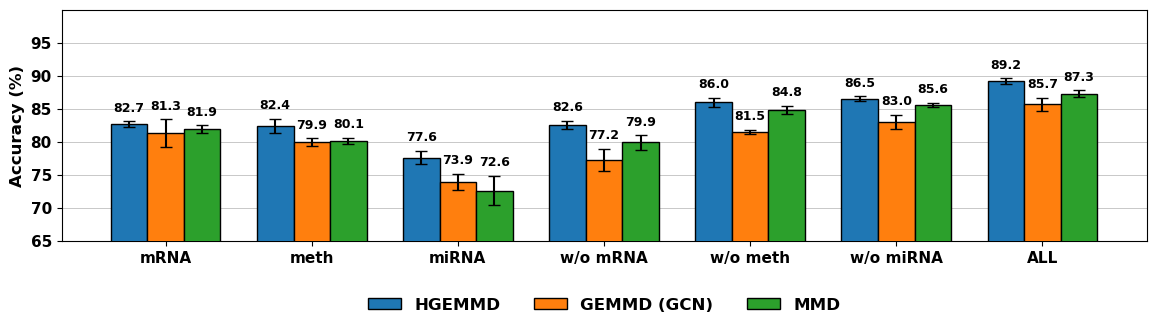

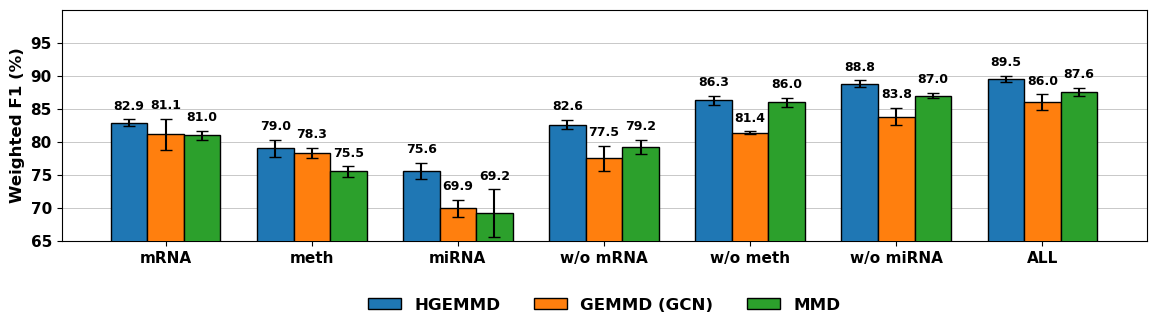

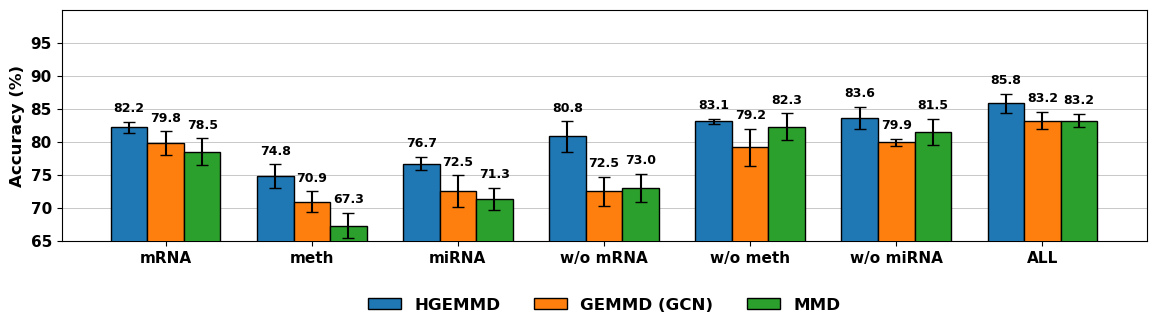

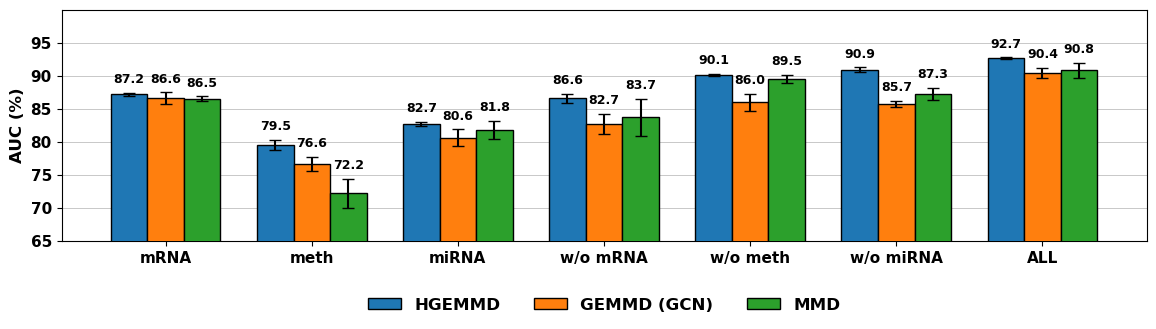

In [7]:
import matplotlib.pyplot as plt
methods = ['HGEMMD', 'GEMMD_GCN', 'MMD']
datasets = ['BRCA', 'ROSMAP']
colors = {'HGEMMD': '#1f77b4', 'GEMMD_GCN': '#ff7f0e', 'MMD': '#2ca02c'}
# colors = {'HGEMMD': '#a1d99b', 'GEMMD_GCN': '#9ecae1', 'MMD': '#fdd49e'} # colors_list = ['#a1d99b', '#9ecae1', '#fdd49e', '#d73027']
modality_dict = {0: 'mRNA', 1: 'meth', 2: 'miRNA', 3: 'w/o mRNA', 4: 'w/o meth', 5: 'w/o miRNA', 6: 'ALL'}

temp_num = 1
for data in datasets:
    metrics = ['ACC', 'F1_weighted'] if data == 'BRCA' else ['ACC', 'AUC']
    for metric in metrics:
        plot_data = pd.read_csv('./figure/data_MOGONET/modality_missing.csv')
        plot_data = plot_data[(plot_data['data'] == data) & (plot_data['metric'] == metric)]
        plot_data = plot_data[['method', 'modality', 'mean', 'std']]
        plot_data = plot_data.sort_values(by=['method', 'modality']).reset_index(drop=True)
    
        plt.figure(figsize=(14, 3))
        for i, method in enumerate(methods):
            g = plot_data[plot_data['method'] == method][['modality', 'mean', 'std']]
            g = g.sort_values(by=['modality']).reset_index(drop=True)
            new_method = method.replace('GEMMD_GCN', 'GEMMD (GCN)')
            x = np.arange(len(modality_dict)); bar_width = 0.25
            plt.bar(x + i * bar_width, g['mean'], width=bar_width, yerr=g['std'], capsize=4, color=colors[method], label=new_method, edgecolor='k', linewidth=1, zorder=3)
            for j in range(len(modality_dict)):
                val = g['mean'][j]
                # plt.text(x[j] + i * bar_width, val + 1.5, f'{val:.1f}', ha='center', fontsize=9, fontweight='bold', fontstyle='italic', color='black', zorder=4)
                plt.text(x[j] + i * bar_width, val + g['std'][j] + 1.5, f'{val:.1f}', ha='center', fontsize=9, fontweight='bold', color='black', zorder=4)
                
        # plt.xticks(x + bar_width, modality_dict.values(), rotation=0, ha='center', fontsize=11, fontweight='bold', fontstyle='italic', color='black')
        # plt.yticks(np.arange(65, 96, 5), fontsize=11, fontweight='bold', fontstyle='italic', color='black')
        plt.xticks(x + bar_width, modality_dict.values(), rotation=0, ha='center', fontsize=11, fontweight='bold', color='black')
        plt.yticks(np.arange(65, 96, 5), fontsize=11, fontweight='bold', color='black')
        plt.ylim(65, 100)
        metric = {'ACC': 'Accuracy (%)', 'F1_weighted': 'Weighted F1 (%)', 'AUC': 'AUC (%)'}[metric]
        # plt.ylabel(f'{metric}', fontsize=12, fontweight='bold', fontstyle='italic', color='black')
        plt.ylabel(f'{metric}', fontsize=12, fontweight='bold', color='black')
        # plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=14, frameon=False, edgecolor='black', prop={'size': 12, 'style': 'italic', 'weight': 'bold'})
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=14, frameon=False, edgecolor='black', prop={'size': 12, 'weight': 'bold'})
        plt.grid(axis='y', linestyle='-', alpha=0.6, linewidth=0.5, color='gray', zorder=0)
        # plt.tight_layout()
        plt.savefig(f'./figure/data_MOGONET/modality_missing_{temp_num}.png', bbox_inches='tight', dpi=300)
        temp_num += 1
        plt.show()

In [ ]:
# t-test the HGEMMD vs GEMMD and HGEMMD vs MMD
# t-stat: represents the difference between the means of the two groups, and p-value: represents the probability of observing the data given that the null hypothesis is true. P<0.05 indicates a significant difference.
import scipy.stats as stats
import pandas as pd

def t_test_combinations(df, method1, method2, metric, seed=42):
    np.random.seed(seed)
    df1 = df[df['method'] == method1]
    df2 = df[df['method'] == method2]
    results = []
    for modality in df1['modality'].unique():
        mean1 = df1.loc[(df1['modality'] == modality) & (df1['metric'] == metric), 'mean'].values[0]
        std1 = df1.loc[(df1['modality'] == modality) & (df1['metric'] == metric), 'std'].values[0]
        values1 = np.random.normal(mean1, std1, 5).round(2)
        mean2 = df2.loc[(df2['modality'] == modality) & (df2['metric'] == metric), 'mean'].values[0]
        std2 = df2.loc[(df2['modality'] == modality) & (df2['metric'] == metric), 'std'].values[0]
        values2 = np.random.normal(mean2, std2, 5).round(2)
        # values1 = df1[df1['modality'] == modality][metric]
        # values2 = df2[df2['modality'] == modality][metric]
        t_stat, p_value = stats.ttest_ind(values1, values2) 
        results.append((modality, t_stat, p_value))
    return results

for data in ['BRCA', 'ROSMAP']:
    for method1, method2 in [('HGEMMD', 'GEMMD_GCN'), ('HGEMMD', 'MMD')]:
        df = pd.read_csv('./figure/data_MOGONET/modality_missing.csv') # ['data', 'metric', 'method', 'modality', 'mean', 'std']
        df = df[(df['data'] == data)][['method', 'modality', 'metric', 'mean', 'std']]
        # df1 = pd.read_csv(f'result/data_MOGONET/{method1}/{data}_modality_missing/metrics.csv')
        # df1['method'] = method1
        # df2 = pd.read_csv(f'result/data_MOGONET/{method2}/{data}_modality_missing/metrics.csv')
        # df2['method'] = method2
        # df = pd.concat([df1, df2], ignore_index=True)
        metrics = ['ACC', 'F1_weighted'] if data == 'BRCA' else ['ACC', 'AUC']
        for metric in metrics:
            results = t_test_combinations(df, method1, method2, metric)
            print(f"T-test results for {method1} vs {method2} on {data} for {metric}:")
            for modality, t_stat, p_value in results:
                print(f"Modality: {modality}, t-statistic: {t_stat:.4f}, p-value: {p_value:.10f}")

T-test results for HGEMMD vs GEMMD_GCN on BRCA for ACC:
Modality: 0, t-statistic: 0.8512, p-value: 0.4193881861
Modality: 1, t-statistic: 4.0784, p-value: 0.0035421816
Modality: 2, t-statistic: 6.9142, p-value: 0.0001227541
Modality: 3, t-statistic: 8.5967, p-value: 0.0000259248
Modality: 4, t-statistic: 15.1979, p-value: 0.0000003481
Modality: 5, t-statistic: 8.2006, p-value: 0.0000365224
Modality: 6, t-statistic: 7.5202, p-value: 0.0000679638
T-test results for HGEMMD vs GEMMD_GCN on BRCA for F1_weighted:
Modality: 0, t-statistic: 1.0943, p-value: 0.3056791333
Modality: 1, t-statistic: 0.2540, p-value: 0.8058990103
Modality: 2, t-statistic: 8.9482, p-value: 0.0000193348
Modality: 3, t-statistic: 7.5137, p-value: 0.0000683848
Modality: 4, t-statistic: 17.7040, p-value: 0.0000001060
Modality: 5, t-statistic: 9.9095, p-value: 0.0000090839
Modality: 6, t-statistic: 5.9837, p-value: 0.0003293302
T-test results for HGEMMD vs MMD on BRCA for ACC:
Modality: 0, t-statistic: 2.8299, p-value: 0

In [ ]:
# Randomly generated data for testing:
# T-test results for HGEMMD vs GEMMD_GCN on BRCA for ACC:
# Modality: 0, t-statistic: 0.8512, p-value: 0.4193881861
# Modality: 1, t-statistic: 4.0784, p-value: 0.0035421816
# Modality: 2, t-statistic: 6.9142, p-value: 0.0001227541
# Modality: 3, t-statistic: 8.5967, p-value: 0.0000259248
# Modality: 4, t-statistic: 15.1979, p-value: 0.0000003481
# Modality: 5, t-statistic: 8.2006, p-value: 0.0000365224
# Modality: 6, t-statistic: 7.5202, p-value: 0.0000679638
# T-test results for HGEMMD vs GEMMD_GCN on BRCA for F1_weighted:
# Modality: 0, t-statistic: 1.0943, p-value: 0.3056791333
# Modality: 1, t-statistic: 0.2540, p-value: 0.8058990103
# Modality: 2, t-statistic: 8.9482, p-value: 0.0000193348
# Modality: 3, t-statistic: 7.5137, p-value: 0.0000683848
# Modality: 4, t-statistic: 17.7040, p-value: 0.0000001060
# Modality: 5, t-statistic: 9.9095, p-value: 0.0000090839
# Modality: 6, t-statistic: 5.9837, p-value: 0.0003293302
# T-test results for HGEMMD vs MMD on BRCA for ACC:
# Modality: 0, t-statistic: 2.8299, p-value: 0.0221531997
# Modality: 1, t-statistic: 3.5886, p-value: 0.0070984352
# Modality: 2, t-statistic: 7.3557, p-value: 0.0000795017
# Modality: 3, t-statistic: 6.5024, p-value: 0.0001876242
# Modality: 4, t-statistic: 3.2500, p-value: 0.0117016583
# Modality: 5, t-statistic: 5.5477, p-value: 0.0005424050
# Modality: 6, t-statistic: 6.5896, p-value: 0.0001712401
# T-test results for HGEMMD vs MMD on BRCA for F1_weighted:
# Modality: 0, t-statistic: 6.0165, p-value: 0.0003175167
# Modality: 1, t-statistic: 5.0595, p-value: 0.0009776734
# Modality: 2, t-statistic: 6.5826, p-value: 0.0001724986
# Modality: 3, t-statistic: 7.3680, p-value: 0.0000785679
# Modality: 4, t-statistic: 0.8978, p-value: 0.3955031757
# Modality: 5, t-statistic: 8.5117, p-value: 0.0000278737
# Modality: 6, t-statistic: 5.1163, p-value: 0.0009112814
# T-test results for HGEMMD vs GEMMD_GCN on ROSMAP for ACC:
# Modality: 0, t-statistic: 2.7987, p-value: 0.0232426459
# Modality: 1, t-statistic: 3.9944, p-value: 0.0039805490
# Modality: 2, t-statistic: 6.0380, p-value: 0.0003100062
# Modality: 3, t-statistic: 6.9019, p-value: 0.0001242882
# Modality: 4, t-statistic: 3.4697, p-value: 0.0084465834
# Modality: 5, t-statistic: 6.9179, p-value: 0.0001223019
# Modality: 6, t-statistic: 1.9955, p-value: 0.0810832748
# T-test results for HGEMMD vs GEMMD_GCN on ROSMAP for AUC:
# Modality: 0, t-statistic: 0.8812, p-value: 0.4039129732
# Modality: 1, t-statistic: 6.5230, p-value: 0.0001835960
# Modality: 2, t-statistic: 6.5444, p-value: 0.0001795240
# Modality: 3, t-statistic: 7.0375, p-value: 0.0001085078
# Modality: 4, t-statistic: 7.1138, p-value: 0.0001006175
# Modality: 5, t-statistic: 23.8246, p-value: 0.0000000103
# Modality: 6, t-statistic: 6.6768, p-value: 0.0001564065
# T-test results for HGEMMD vs MMD on ROSMAP for ACC:
# Modality: 0, t-statistic: 4.1081, p-value: 0.0033994043
# Modality: 1, t-statistic: 7.9069, p-value: 0.0000475035
# Modality: 2, t-statistic: 8.8370, p-value: 0.0000211919
# Modality: 3, t-statistic: 6.6370, p-value: 0.0001629840
# Modality: 4, t-statistic: 1.3810, p-value: 0.2046148672
# Modality: 5, t-statistic: 2.2294, p-value: 0.0563491998
# Modality: 6, t-statistic: 2.3747, p-value: 0.0449173867
# T-test results for HGEMMD vs MMD on ROSMAP for AUC:
# Modality: 0, t-statistic: 3.8431, p-value: 0.0049257726
# Modality: 1, t-statistic: 11.3688, p-value: 0.0000032326
# Modality: 2, t-statistic: 3.2190, p-value: 0.0122578474
# Modality: 3, t-statistic: 4.1897, p-value: 0.0030388371
# Modality: 4, t-statistic: 2.5117, p-value: 0.0362755940
# Modality: 5, t-statistic: 10.1492, p-value: 0.0000075990
# Modality: 6, t-statistic: 3.1748, p-value: 0.0130994614

In [ ]:
# Real data for testing:
# T-test results for HGEMMD vs GEMMD_GCN on BRCA for ACC:
# Modality: 0, t-statistic: 7.7291, p-value: 0.0000559073
# Modality: 1, t-statistic: 6.4866, p-value: 0.0001907780
# Modality: 2, t-statistic: 13.0212, p-value: 0.0000011479
# Modality: 3, t-statistic: 10.2799, p-value: 0.0000069046
# Modality: 4, t-statistic: 29.4217, p-value: 0.0000000019
# Modality: 5, t-statistic: 12.2687, p-value: 0.0000018106
# Modality: 6, t-statistic: 32.7660, p-value: 0.0000000008
# T-test results for HGEMMD vs GEMMD_GCN on BRCA for F1_weighted:
# Modality: 0, t-statistic: 7.0629, p-value: 0.0001058063
# Modality: 1, t-statistic: 5.2918, p-value: 0.0007356226
# Modality: 2, t-statistic: 11.2714, p-value: 0.0000034505
# Modality: 3, t-statistic: 10.1365, p-value: 0.0000076705
# Modality: 4, t-statistic: 36.6668, p-value: 0.0000000003
# Modality: 5, t-statistic: 11.0308, p-value: 0.0000040621
# Modality: 6, t-statistic: 28.6866, p-value: 0.0000000024
# T-test results for HGEMMD vs MMD on BRCA for ACC:
# Modality: 0, t-statistic: 11.0432, p-value: 0.0000040279
# Modality: 1, t-statistic: 16.0451, p-value: 0.0000002284
# Modality: 2, t-statistic: 9.4770, p-value: 0.0000126571
# Modality: 3, t-statistic: 4.8536, p-value: 0.0012660072
# Modality: 4, t-statistic: 7.6014, p-value: 0.0000629670
# Modality: 5, t-statistic: 7.7152, p-value: 0.0000566352
# Modality: 6, t-statistic: 8.5524, p-value: 0.0000269219
# T-test results for HGEMMD vs MMD on BRCA for F1_weighted:
# Modality: 0, t-statistic: 10.3649, p-value: 0.0000064912
# Modality: 1, t-statistic: 13.6728, p-value: 0.0000007885
# Modality: 2, t-statistic: 9.1529, p-value: 0.0000163692
# Modality: 3, t-statistic: 5.8521, p-value: 0.0003818581
# Modality: 4, t-statistic: 7.5499, p-value: 0.0000660876
# Modality: 5, t-statistic: 6.8656, p-value: 0.0001289383
# Modality: 6, t-statistic: 7.5964, p-value: 0.0000632630
# T-test results for HGEMMD vs GEMMD_GCN on ROSMAP for ACC:
# Modality: 0, t-statistic: 7.0895, p-value: 0.0001030576
# Modality: 1, t-statistic: 8.2443, p-value: 0.0000351426
# Modality: 2, t-statistic: 10.3422, p-value: 0.0000065988
# Modality: 3, t-statistic: 7.4501, p-value: 0.0000726354
# Modality: 4, t-statistic: 6.2961, p-value: 0.0002337761
# Modality: 5, t-statistic: 7.0711, p-value: 0.0001049536
# Modality: 6, t-statistic: 6.3324, p-value: 0.0002248198
# T-test results for HGEMMD vs GEMMD_GCN on ROSMAP for AUC:
# Modality: 0, t-statistic: 8.4829, p-value: 0.0000285684
# Modality: 1, t-statistic: 14.6669, p-value: 0.0000004586
# Modality: 2, t-statistic: 21.6726, p-value: 0.0000000217
# Modality: 3, t-statistic: 11.9034, p-value: 0.0000022800
# Modality: 4, t-statistic: 11.9400, p-value: 0.0000022274
# Modality: 5, t-statistic: 20.7866, p-value: 0.0000000301
# Modality: 6, t-statistic: 9.7279, p-value: 0.0000104254
# T-test results for HGEMMD vs MMD on ROSMAP for ACC:
# Modality: 0, t-statistic: 7.8184, p-value: 0.0000514975
# Modality: 1, t-statistic: 12.9653, p-value: 0.0000011864
# Modality: 2, t-statistic: 14.9681, p-value: 0.0000003918
# Modality: 3, t-statistic: 7.1767, p-value: 0.0000945838
# Modality: 4, t-statistic: 3.0305, p-value: 0.0162980673
# Modality: 5, t-statistic: 1.7844, p-value: 0.1121885229
# Modality: 6, t-statistic: 2.4000, p-value: 0.0431767278
# T-test results for HGEMMD vs MMD on ROSMAP for AUC:
# Modality: 0, t-statistic: 26.0643, p-value: 0.0000000050
# Modality: 1, t-statistic: 14.2812, p-value: 0.0000005636
# Modality: 2, t-statistic: 18.1295, p-value: 0.0000000880
# Modality: 3, t-statistic: 6.0693, p-value: 0.0002994554
# Modality: 4, t-statistic: 11.6369, p-value: 0.0000027085
# Modality: 5, t-statistic: 10.4253, p-value: 0.0000062144
# Modality: 6, t-statistic: 4.5904, p-value: 0.0017776668